In [1]:
import numpy as np
import pandas as pd
import re # Regular expression library


# Silence warnings
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import seaborn as sns

#image downloard
import os as os


path_to_dta = '/Users/zhaomengshan/Desktop/Organic_Agri/Data/organic_baseline.dta'
path_to_excel = '/Users/zhaomengshan/Desktop/Organic_Agri/Data/Encoder Sheet 001-600 100423.xlsx'

# Loading the .dta file
baseline = pd.read_stata(path_to_dta)

# Loading the Excel file
endline = pd.read_excel(path_to_excel)

In [2]:
baseline.head()

,householdid,hhname,zone,barangay,municipality,landmark,mobile_1,mobile_2,visit,a1,...,var843,var844,var845,var846,var847,var848,var849,var850,var851,var852
0,161,Rey Contento,Kabukiran,Oobi,Majayjay,Dulo ng Bukid,9.618016e+09,NaN,1,6,...,1,1,1,1,1,1,1,1,1,1
1,162,Wenifredo Aranillo,Kabukiran,Oobi/Sta. Catalina,Majayjay,Dulo ng Bukid,9.618016e+09,NaN,1,7,...,1,1,1,1,1,1,1,1,1,1
2,163,Honorio Prialde,Kabukiran,Oobi,Majayjay,Papasok sa gate,9.657033e+09,NaN,1,5,...,1,1,1,1,1,1,1,1,1,1
3,164,Bernadino Borines,Kabukiran,Oobi,Majayjay,Ilayang banga daycare,9.058964e+09,NaN,1,4,...,1,1,1,1,1,1,1,1,1,1
4,165,Maximo B. Arsolacia,Kabukiran,Oobi,Majayjay,Near barangay hall,9.954021e+09,9.975632e+09,1,3,...,1,1,1,1,1,1,1,1,1,1


In [3]:
endline.head()

,HouseholdID,HHName,Zone,Barangay,Municipality,Landmark,Mobile_1,Mobile_2,Visit,Spouseseparate,...,130_f,145_f,200_f,215_f,230_f,245_f,300_f,315_f,330_f,345_f
0,1,Rizaldy Ologeñio,7,Silangan Lazaan,Nagcarlan,malapit sa tower,9.770572e+09,NaN,2.0,No,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,2,Edelberto Doria,7,Silangan Lazaan,Nagcarlan,"ilaya, malapit sa tower",9.056325e+09,NaN,2.0,Yes,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,3,Mauro Coronato,7,Silangan Lazaan,Nagcarlan,signage ng purok 7,9.975908e+09,NaN,2.0,Yes,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,4,Marvin Coronado,7,Silangan Lazaan,Nagcarlan,malapit sa globe towet,9.977721e+09,NaN,2.0,Yes,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,5,Mark Joel Doria,6,Silangan Lazaan,Nagcarlan,malapit sa tindahan (rose),9.276386e+10,NaN,2.0,Yes,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [4]:
# Ensure the ID columns are of the same type- string
baseline['householdid'] = baseline['householdid'].astype(str)
endline['HouseholdID'] = endline['HouseholdID'].astype(str)

# Merge the datasets on household ID
merged_data = pd.merge(baseline, endline, how='outer', left_on='householdid', right_on='HouseholdID', indicator=True)

# 1) Print cases where household names differ
discrepancies = merged_data[(merged_data['hhname'] != merged_data['HHName']) & (merged_data['_merge'] == 'both')]
print("Discrepancies in household names:")
print(discrepancies[['householdid', 'hhname', 'HHName']])
discrepancies[['householdid', 'hhname', 'HHName']].to_csv('/Users/zhaomengshan/Desktop/Organic_Agri/Data/discrepancies.csv', index=False)

# 2) Print out cases where household IDs are only in the baseline
missing_in_endline = merged_data[merged_data['_merge'] == 'left_only']
print("Households present in baseline but not in endline:")
print(missing_in_endline[['householdid', 'hhname']])

# 3) Print out duplicate household ID for endline (no duplicate in the baseline)
duplicates = endline[endline.duplicated(subset=['HouseholdID'], keep=False)]
print("Duplicate Entries based on endline:")
print(duplicates[['HouseholdID', 'HHName']])

Discrepancies in household names:
    householdid                 hhname                     HHName
3           164      Bernadino Borines         Bernardino Briones
4           165    Maximo B. Arsolacia           Maximo Arsolacio
7           168       Marlon C. Dorado              Marlon Dorado
25          186  Saturnino A. Raya Jr.         Saturnino Raya jr.
26          187       Loreto V. Brosas              Loreto Brosas
..          ...                    ...                        ...
573         444        Romeo De Gusman            Romeo De Guzman
574         445       Jerry Lacostales           Jerry Lacostules
586         457            Resty leysa                Resty Leysa
589         460       Rolando Aliliran            Justin Aliliran
598         469         Reydante Obias  Reydante Obias (Deceased)

[150 rows x 3 columns]
Households present in baseline but not in endline:
    householdid                hhname
126         501     Toribio Malabanan
190         565        

In [5]:
# For the duplicate
# Eyeball check: all major numeric variables are the same, except the variable lastlearn


ids_to_check = ['83', '86', '100', '102']


filtered_data = endline[endline['HouseholdID'].isin(ids_to_check)]


print("Filtered Entries for specified HouseholdIDs:")
print(filtered_data)

numeric_data = filtered_data.select_dtypes(include=[np.number])

# Checking if numeric entries for each HouseholdID are identical
for id_ in ids_to_check:
    group = numeric_data[filtered_data['HouseholdID'] == id_]
    # Drop the ID column for comparison since it will be the same for the group
    if not group.empty:
        unique_rows = group.drop_duplicates()
        is_identical = unique_rows.shape[0] == 1
        print(f"All numeric entries for HouseholdID {id_} are identical: {is_identical}")
    else:
        print(f"No numeric data available for comparison for HouseholdID {id_}")


Filtered Entries for specified HouseholdIDs:
    HouseholdID            HHName Zone         Barangay Municipality  \
79           83   Rogelio Trilana    4  Silangan Lazaan    Nagcarlan   
80           83  Rogelio Trillana    4  Silangan Lazaan    Nagcarlan   
83           86  Siprino Coronado    7  Silangan Lazaan    Nagcarlan   
84           86  Siprino Coronado    7  Silangan Lazaan    Nagcarlan   
98          100   Cirilo Coronado    7  Silangan Lazaan    Nagcarlan   
99          100   Cirilo Coronado    7  Silangan Lazaan    Nagcarlan   
101         102       Noel Dorado    6  Silangan Lazaan    Nagcarlan   
102         102       Noel Dorado    6  Silangan Lazaan    Nagcarlan   

                        Landmark      Mobile_1  Mobile_2  Visit  \
79                        Ermita  9.363228e+09       NaN    2.0   
80                        Ermita  9.363228e+09       NaN    2.0   
83   katabi ng bagsakan ng gulay  9.262727e+09       NaN    2.0   
84   katabi ng bagsakan ng gulay  9.26

In [6]:
# For the Discrepancies in household names, we can do
# 1) Eyeball check
# 2) Use simple NLP method to calculate the distance between the two names, and only print out if they are more than 80% different

from fuzzywuzzy import fuzz

# Function to apply fuzzy matching and filter significantly different names
def filter_significant_differences(row, threshold=80):
    # This uses the token sort ratio, which ignores word order and only focuses on the tokens themselves
    similarity = fuzz.token_sort_ratio(row['hhname'], row['HHName'])
    return similarity < threshold

# Apply the function to your discrepancies DataFrame
discrepancies['significant_difference'] = discrepancies.apply(filter_significant_differences, axis=1)

# Filter to get only significant differences
significant_discrepancies = discrepancies[discrepancies['significant_difference']]
significant_discrepancies = significant_discrepancies[['householdid', 'hhname', 'HHName']]
significant_discrepancies


# I think we need to take a look at 233,244,573,83,300,460- some of them shared the same surname, are they just husband and wife
# Drop list: 233 244 60 

,householdid,hhname,HHName
72,233,Mike Mauro,Mauro Lacorte
83,244,Ricky Garcia,Ricky Reyes
107,482,Eduardo Arabis,Eduardo Arabis (Hiwalay sa asawa)
116,491,John Emmanuel Arcenal,John Arcenal
135,510,Tomas Garcia,Tomas Garcia (namatay si misis nung december p...
175,550,Omar Atienza,Omar Atienze(Deceased)
184,559,Reynaldo Guera,Reynaldo Guera(did not plant 2022 3rd quarter ...
198,573,James Francia,Tomas Francia
255,32,Joel U. Ondino,Joel Condino
260,37,Eduardo Dorado,Eduardo Dorado (refused)


# Asset- M1

# Consumption and Expenditure- M2

# Adoption- M4

# Labor- M4

# Male Time Use- M5

# Expenditure by Female- F3

# Children Nutrition- F4

# Child Anthropometrics- F5

# Female Time Use- F6

# Women Empowerment Index

In [54]:
# Fill the NA

# Select the important variables in the merged_data


# dietary diversity 
base_columns = [
    'othermilk_hh', 'breadrice_hh', 'rootc_hh', 'veg_hh', 'fruit_hh',
    'karne_hh', 'egg_hh', 'isda_hh', 'beans_hh', 'oil_hh', 'sugar_hh', 'condiment_hh'
]


dd_outcomes = [col + '_x' for col in base_columns]


labor_categories = [
    "land", "nurs", "plant", "prune", "fert", "pest", "irrig", "weed", "harv", "trans", "mark", "oth"
]


labor_vars = []
for category in labor_categories:
    labor_vars.append(f"{category}_total_labor_x")
    
# labor outcomes
labor_vars1 = [
    "lab_land_fam_m_tot", "lab_land_fam_f_tot", "lab_land_hir_tot",
    "lab_nurs_fam_m_tot", "lab_nurs_fam_f_tot", "lab_nurs_hir_tot",
    "lab_plant_fam_m_tot", "lab_plant_fam_f_tot", "lab_plant_hir_tot",
    "lab_prune_fam_m_tot", "lab_prune_fam_f_tot", "lab_prune_hir_tot",
    "lab_fert_fam_m_tot", "lab_fert_fam_f_tot", "lab_fert_hir_tot",
    "lab_pest_fam_m_tot", "lab_pest_fam_f_tot", "lab_pest_hir_tot",
    "lab_irrig_fam_m_tot", "lab_irrig_fam_f_tot", "lab_irrig_hir_tot",
    "lab_weed_fam_m_tot", "lab_weed_fam_f_tot", "lab_weed_hir_tot",
    "lab_harv_fam_m_tot", "lab_harv_fam_f_tot", "lab_harv_hir_tot",
    "lab_trans_fam_m_tot", "lab_trans_fam_f_tot", "lab_trans_hir_tot",
    "lab_mark_fam_m_tot", "lab_mark_fam_f_tot", "lab_mark_hir_tot"
]

labor_vars = [col + '_x' for col in labor_vars1]

# Same consumption indices with the addition of suffixes
consumption_indices = ['aglandall', 'exp_m_x', 'exp_f_x', 'exp_hh_x', 'hdd_x']



# Combine relevant variables
rel_vars1 = ['fert_x', 'herb_x','q_1','q_2','q_3','q_4','q_5','q2he','q3he','q4he','q5he']

# Extract labor and consumption variables
labor = merged_data[labor_vars]
consumption = merged_data[rel_vars1 + consumption_indices]

other = ['householdid','gen_index','gen_index1','gen_index2','Weekend']


indices = labor_vars + consumption_indices + rel_vars1 +other + dd_outcomes
features1 = merged_data[indices]




features1.set_index('householdid', inplace=True, drop=True)
asset.set_index('householdid', inplace=True, drop=True)
timeuse.set_index('householdid', inplace=True, drop=True)



# Merge features1 and asset, then merge the result with timeuse
features = features1.merge(asset, left_index=True, right_index=True, how='inner')
features = features.merge(timeuse, left_index=True, right_index=True, how='inner')


# replace Inf to NA
#features['gen_index'].replace([np.inf, -np.inf], np.nan, inplace=True)
features = features.replace([np.inf, -np.inf], np.nan)

subset_df = features[features['gen_index'].notna()]
missing_df = features[features['gen_index'].isna()]


print(subset_df.shape)
print(missing_df.shape)


(376, 161)
(224, 161)


In [55]:
target=['gen_index','gen_index1','gen_index2']

y= subset_df['gen_index']
y1= subset_df['gen_index1']
y2 =subset_df['gen_index2']


X= subset_df.drop(target,axis=1)
x1 = subset_df.dropna()
X_complete=x1.drop(['gen_index','gen_index1','gen_index2'],axis=1)

y_complete= x1['gen_index']


X_missing= missing_df.drop(['gen_index','gen_index1','gen_index2'],axis=1)
X_missing=X_missing.dropna()

print(X.shape)

print(X_complete.shape)
print(y_complete.shape)
print(X_missing.shape)


(376, 158)
(375, 158)
(375,)
(224, 158)


In [56]:
# Import train_test_split
from sklearn.model_selection import train_test_split

from sklearn.model_selection import cross_val_score

# Import GridSearchCV
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, KFold

from sklearn.neighbors import KNeighborsRegressor

#XGBoost
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
import xgboost as xgb

from xgboost import plot_importance


from sklearn.metrics import mean_squared_error, make_scorer, r2_score, accuracy_score, f1_score, confusion_matrix

import shap as shap



K=30

Knum= list(range(1,30,1))
leaf= list(range(1,50,1))
params={'n_neighbors':Knum}
parameters_KNN1 = {
    'n_neighbors': Knum,
    'leaf_size': leaf,
    'p': (1,2),
    'weights': ('uniform', 'distance'),
    'metric': ('minkowski', 'chebyshev')}

parameters_KNN2 = {
    'n_neighbors': Knum,
    'leaf_size': leaf}

param_grid = {
    'n_neighbors': Knum,  # Example values for K
    'weights': ['uniform', 'distance'],  # Weighting scheme
    'metric': ['euclidean', 'manhattan'],  # Distance metric
}

knn = KNeighborsRegressor(n_neighbors=30, weights='distance')
kfold = KFold(n_splits=5, shuffle=True, random_state=2) 

X_train, X_test, y_train, y_test = train_test_split(X_complete, y_complete, test_size=0.20, random_state=2)


In [57]:

knn.fit(X_train, y_train)
#KNNgrid.fit(X_complete, y_complete)

# Extract best params
#best_params = KNNgrid.best_params_

# Print best params
#print("Best params:", best_params)

# Compute best score
#best_score = KNNgrid.best_score_
# Print best score
#print("Best score: {:.5f}".format(best_score))


y_pred = knn.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

1.365201443185708


(224, 159)
0
householdid
161    0.639
162    0.614
163    0.672
171   -0.101
172    0.518
       ...  
468    0.409
469    0.346
472    0.617
473    0.614
474    0.396
Name: gen_index, Length: 224, dtype: float64


array([[<AxesSubplot:title={'center':'gen_index'}>]], dtype=object)

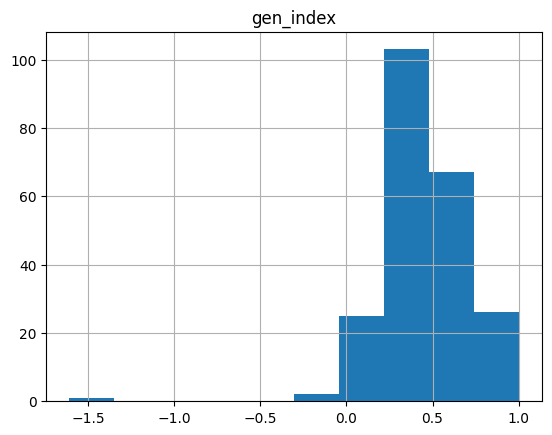

In [58]:
knn.fit(X_complete, y_complete)

# Predict missing values using the K-NN classifier
imputed_values = knn.predict(X_missing)
#Knnbest_estim=KNNgrid.best_estimator_
#imputed_values =Knnbest_estim.predict(X_missing)

Missing= X_missing
# Assign the imputed values to the missing data
Missing['gen_index'] = imputed_values

print(Missing.shape)
print(Missing.isna().sum().sum())
print(Missing['gen_index'])

pd.DataFrame(Missing['gen_index']).hist()



In [59]:
A = pd.concat([X_complete, y_complete], axis=1)

B = pd.concat([A, Missing])

print(A.isna().sum().sum())
print(B.isna().sum())
print(B.shape)


X= B.drop('gen_index',axis=1)
Y = B['gen_index']

print(A['gen_index'].unique())
print(Y.shape)



Y.head()

0
lab_land_fam_m_tot_x    0
lab_land_fam_f_tot_x    0
lab_land_hir_tot_x      0
lab_nurs_fam_m_tot_x    0
lab_nurs_fam_f_tot_x    0
                       ..
time_exercise_f         0
time_social_f           0
time_religious_f        0
time_other_f            0
gen_index               0
Length: 159, dtype: int64
(599, 159)
[ 0.          1.5         0.66666667 -1.          0.33333333  0.75
  1.          3.          0.6        -2.          0.25       -4.
  0.5        -1.5        -6.          2.5         5.          2.
  3.33333333  1.33333333  0.625       1.66666667 -0.25       -0.5
  4.         -3.          0.8         3.5         1.75       -0.14285714
  1.2        -0.75       -5.          0.83333333 -0.33333333  0.28571429
  0.4         1.25        6.         -0.66666667  7.          1.28571429]
(599,)


householdid
164    0.000
165    1.500
166    0.667
167   -1.000
168    0.333
Name: gen_index, dtype: float64

In [60]:

#rename variables from dictionary 
#X.rename(columns=column_mapping, inplace=True)
#agland.rename(columns=column_mapping, inplace=True)



# # Include Z scores for height and weight of children
zscores = pd.read_csv('/Users/zhaomengshan/Desktop/Organic_Agri/Code/Archive/zscore.csv')


#zscores = merged_children_data[['HouseholdID', 'HAZ_base', 'WAZ_base']]
zscores.set_index('householdid', inplace=True)
zscores = zscores.apply(pd.to_numeric, errors='coerce')
#drop duplicate 

# Drop duplicates in zscores if there are any
zscores = zscores[~zscores.index.duplicated(keep='first')]


#left join by index 
X = X.merge(zscores, how='left', left_index=True, right_index=True)
print(zscores.shape)




z_features = zscores.columns.tolist()




print(X.shape)




#Y=Y.to_frame()



round(Y.describe(),2)


# # XGBOOST



xtrain, xtest, ytrain, ytest=train_test_split(X, Y, test_size=0.20, random_state=2)



#xgboost model
model = XGBRegressor(booster='gbtree', objective='reg:squarederror',n_estimators=100, random_state=2, n_jobs=-1)


# In[53]:


nestimators= list(range(1,100,1))
depth= list(range(1,15,1))
params1={'colsample_bylevel':[0.1,0.2,0.3,0.4,0.5, 0.6, 0.7, 0.8, 0.9, 1],
                    'subsample':[0.5, 0.6, 0.7, 0.8, 0.9, 1], 
                    'min_child_weight':[1, 2, 3, 4, 5], 
                    'learning_rate':[0.05,0.0025,0.06,0.07,0.08], 
                    'max_depth':depth, 
                    'n_estimators':nestimators,
                    'gamma':[0.10,0.2,0.3,0.4,0.5,1,2,3,4,5,6,7,8,8,10,11]}
#'gamma':[0,0.1,0.5,1,2,5]
#params={'max_depth':[1, 2, 3, 4, 5, None],'n_estimators':[2,10, 25, 50,60, 75, 100,150,200], 'learning_rate':[0.1, 0.2, 0.3, 0.4, 0.5]}

nestimators2= list(range(1,400,1))
#params2={'max_depth':depth,'n_estimators':nestimators2, 'learning_rate':[0.05,0.0025,0.06,0.07,0.1]}
params2={'max_depth':[1, 2, 3, 4, 5, None],'n_estimators':nestimators, 'learning_rate':[0.05,0.0025,0.06,0.07,0.1, 0.2, 0.3, 0.4, 0.5]}


scorer = make_scorer(mean_squared_error)
neg= 'neg_mean_squared_error'
kfold = KFold(n_splits=5, shuffle=True, random_state=2)   

grid= RandomizedSearchCV(model, params1, cv=kfold, n_iter=300, n_jobs=-1, random_state=2, scoring=scorer,return_train_score=True)
#grid= GridSearchCV(model, params2, cv=kfold, n_jobs=-1, scoring=scorer,return_train_score=True)


(600, 2)
(599, 160)


In [61]:
xtrain = xtrain.apply(pd.to_numeric, errors='coerce')
ytrain = ytrain.apply(pd.to_numeric, errors='coerce')
print(np.isinf(xtrain).any().sum(), np.isinf(ytrain).any())

xtest = xtest.apply(pd.to_numeric, errors='coerce')
ytest = ytest.apply(pd.to_numeric, errors='coerce')

0 False


In [62]:
grid.fit(xtrain, ytrain)
#early stopping
#eval_set = [(xtest, ytest)]  # Validation dataset
#grid.fit(xtrain, ytrain, eval_set=eval_set, early_stopping_rounds=5)

print(grid.best_params_)


# In[54]:


best_estim=grid.best_estimator_
print(best_estim)

{'subsample': 0.7, 'n_estimators': 77, 'min_child_weight': 1, 'max_depth': 11, 'learning_rate': 0.08, 'gamma': 0.5, 'colsample_bylevel': 0.7}
XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=0.7, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0.5, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.08, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=11, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=77, n_jobs=-1,
             num_parallel_tree=1, predictor='auto', random_state=2, reg_alpha=0,
             reg_lambda=1, ...)


In [63]:
ytr_pred=best_estim.predict(xtrain)
mse1 = mean_squared_error(ytrain,ytr_pred)
rmse1=np.sqrt(mse1)

r2 = r2_score(ytrain,ytr_pred)


best_score = grid.best_score_
rmse2 = np.sqrt(best_score)
mse = best_score

print("MSE: %.2f" % mse)
print('RMSE as a whole:', np.round(rmse1, 3))
print('RMSE k folds:', np.round(rmse2, 3))
print("R2: %.2f" % r2)

MSE: 1.32
RMSE as a whole: 0.258
RMSE k folds: 1.15
R2: 0.94


count   479.000
mean      0.437
std       1.061
min      -6.000
25%       0.000
50%       0.460
75%       0.905
max       7.000
Name: gen_index, dtype: float64


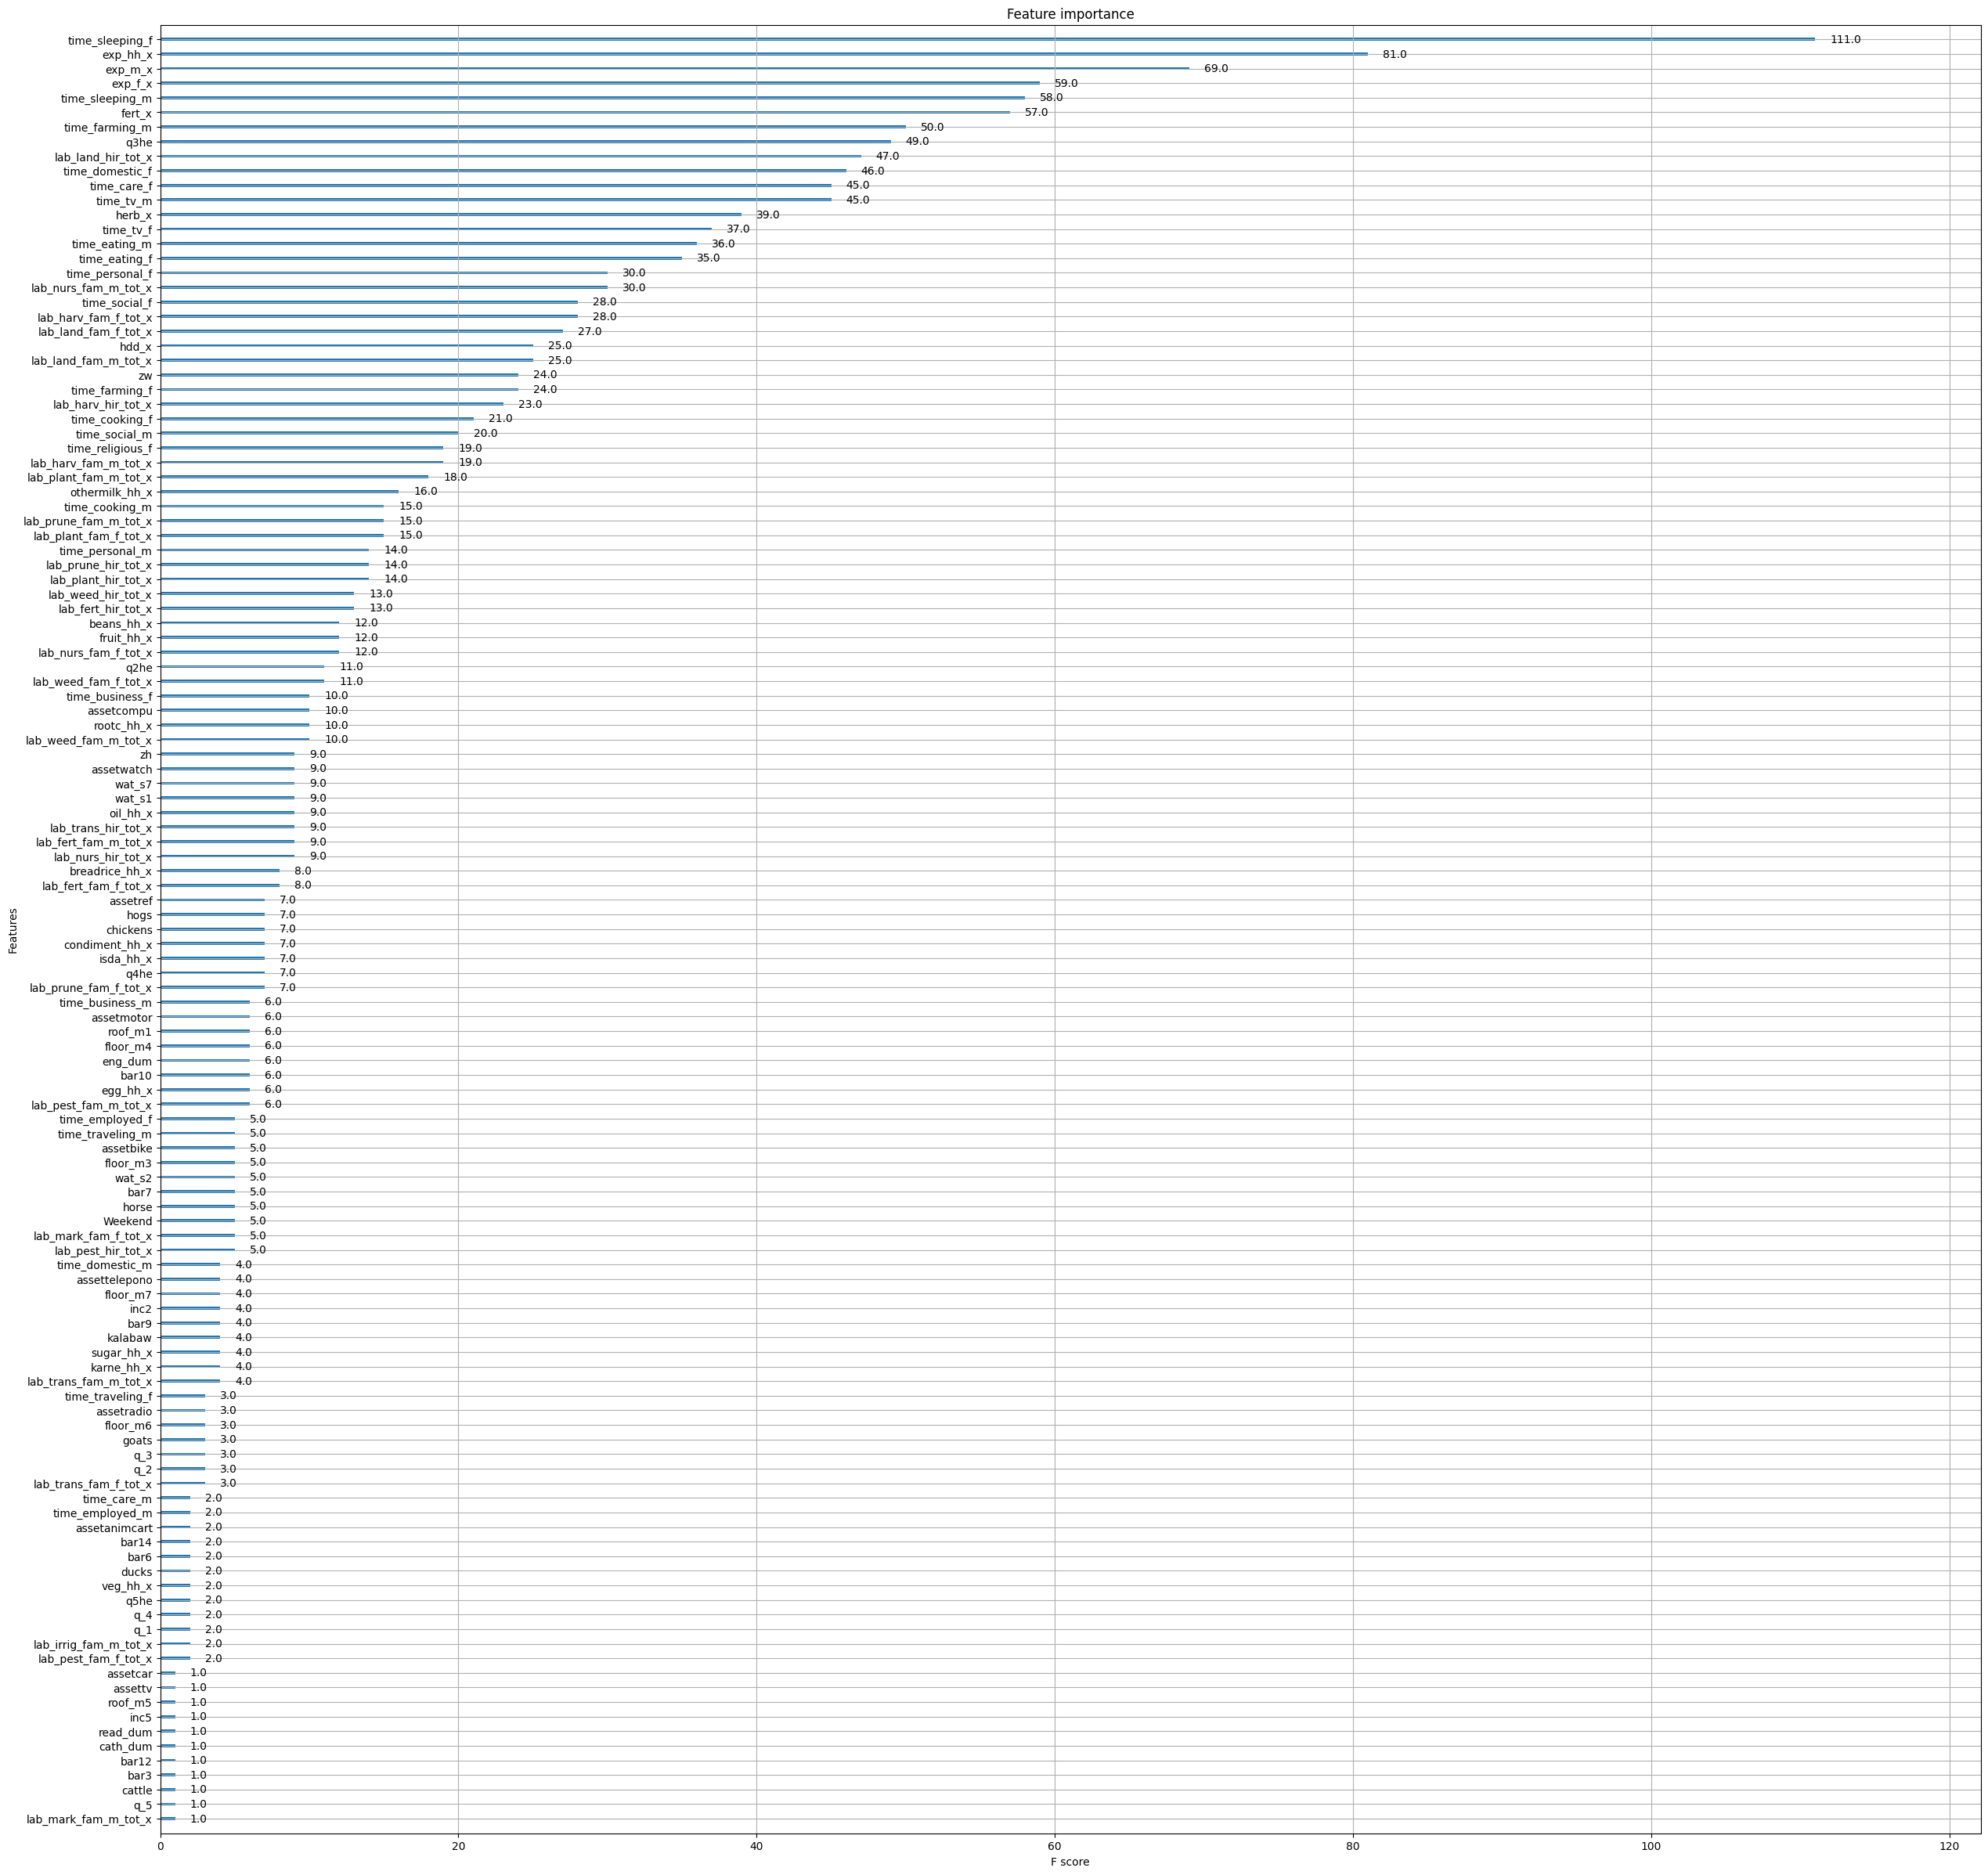

In [64]:
plot= plot_importance(grid.best_estimator_,importance_type='weight')
fig = plot.figure
fig.set_size_inches(30, 30)


print(ytrain.describe())


In [65]:
best_xgboost_model = grid.best_estimator_
importance_scores = best_xgboost_model.feature_importances_
num_features_with_score_at_least_1 = sum(importance > 0 for importance in importance_scores)

num_features = len(importance_scores)
print(f"Number of important features with score > 0: {num_features_with_score_at_least_1} out of {num_features}")


Number of important features with score > 0: 123 out of 160


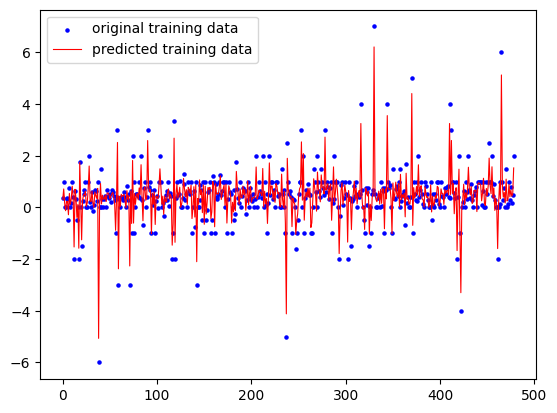

In [66]:
x_ax = range(len(ytrain))
plt.scatter(x_ax, ytrain, s=5, color="blue", label="original training data")
plt.plot(x_ax, ytr_pred, lw=0.8, color="red", label="predicted training data")
plt.legend()
plt.show()


In [67]:
booster = best_estim.get_booster()
feature_importances = booster.get_score(importance_type='weight')

df_fi = pd.DataFrame([feature_importances])
df_fi['Features']=df_fi.index

#df_fi = pd.DataFrame(feature_importances, columns=['Feature', 'F-Score'])
#df_fi.to_csv('/Users/namloc/Downloads/feature_fscore_df12.csv', index=False)

transpose= df_fi.transpose()
transpose=transpose.reset_index()

transpose.columns = ['Features', 'F-Score']
transpose= transpose[:-1]

#transpose.to_csv('/Users/namloc/Downloads/feature_fscore_df123.csv', index=False)
featureImp= transpose.sort_values(by='F-Score', ascending=False)
featureImp.head(40)
featureImp.shape

(123, 2)

MSE: 1.89
RMSE: 1.376
R2: -0.14


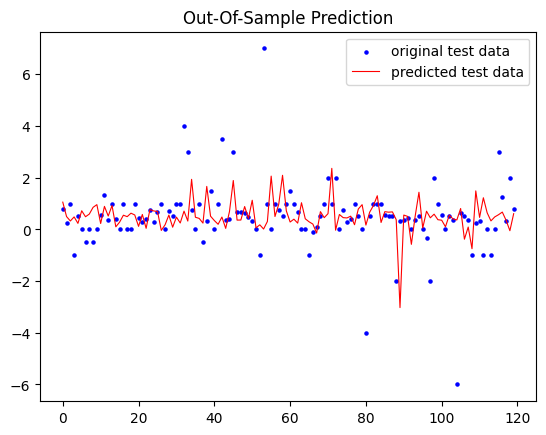

count   120.000
mean      0.499
std       1.291
min      -6.000
25%       0.000
50%       0.500
75%       1.000
max       7.000
Name: gen_index, dtype: float64


In [68]:
#out-of-sample prediction
ypred=best_estim.predict(xtest)
mse = mean_squared_error(ytest, ypred)
rmse=np.sqrt(mse)

print("MSE: %.2f" % mse)
print('RMSE:', np.round(rmse, 3))

r2 = r2_score(ytest, ypred)
print("R2: %.2f" % r2)

x_ax = range(len(ytest))
plt.scatter(x_ax, ytest, s=5, color="blue", label="original test data")
plt.plot(x_ax, ypred, lw=0.8, color="red", label="predicted test data")
plt.legend()
plt.title("Out-Of-Sample Prediction")
plt.show()

print(ytest.describe())


Standard Deviation: 1.109088895524127


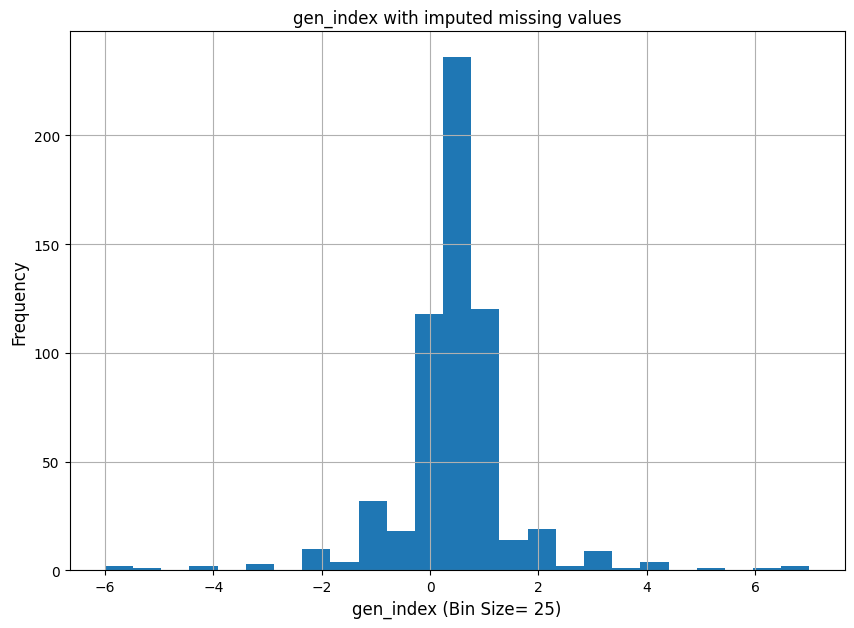

<Figure size 10000x10000 with 0 Axes>

In [69]:

fig = plt.figure(figsize=(10,7))
ax = fig.gca()

Y.hist(bins=25,ax=ax)

plt.title("gen_index with imputed missing values",fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlabel('gen_index (Bin Size= 25)', fontsize=12)
plt.figure(figsize=(100,100))
print(f'Standard Deviation: {np.std(Y)}')


In [70]:
# Get the indices of rows with originally missing gen_index values
originally_missing_indices = features[features['gen_index'].isna()].index

# Create a dataframe that will contain only the predictions for originally missing values
missing_predictions = pd.DataFrame()

# For test set predictions, only keep those that were originally missing
ypred_df = pd.DataFrame(ypred, columns=['wei_predicted'])
ypred_df['householdid'] = xtest.index
missing_test_preds = ypred_df[ypred_df['householdid'].isin(originally_missing_indices)]

# For training set predictions, only keep those that were originally missing
ytr_pred_df = pd.DataFrame(ytr_pred, columns=['wei_predicted'])
ytr_pred_df['householdid'] = xtrain.index
missing_train_preds = ytr_pred_df[ytr_pred_df['householdid'].isin(originally_missing_indices)]

# Combine all predictions 
all_predictions = pd.concat([ypred_df, ytr_pred_df])

# Create a complete dataset with both original and predicted values
complete_data = features.copy()

# Create a new column for predictions
complete_data['gen_index_predicted'] = np.nan

# Fill in predictions for all rows that have them
predictions_dict = dict(zip(all_predictions['householdid'], all_predictions['wei_predicted']))
complete_data['gen_index_predicted'] = complete_data.index.map(predictions_dict)

# Create a new column for the final values
complete_data['gen_index_final'] = complete_data['gen_index'].copy()

# Fill in missing values with predictions
complete_data.loc[originally_missing_indices, 'gen_index_final'] = complete_data.loc[originally_missing_indices, 'gen_index_predicted']

# Handle values that are exactly 0.5
exact_half_indices = complete_data[complete_data['gen_index'] == 0.5].index
for idx in exact_half_indices:
    if idx in predictions_dict:
        if predictions_dict[idx] > 0.5:
            complete_data.loc[idx, 'gen_index_final'] = 0.51  # Slightly above 0.5
        else:
            complete_data.loc[idx, 'gen_index_final'] = 0.49  # Slightly below 0.5

# Save the complete dataset with original, predicted, and final values
complete_data.to_csv('/Users/zhaomengshan/Desktop/Organic_Agri/Data/wei_combined_values.csv')


# Treatment/ Control

# Check balance of the baseline

# Summary Statistic Table